# Analysis

Sentiment, categorization, clustering, and Plotly exploration for the discovery
records. The same pipeline is applied to both **challenges** and **expectations**.

Section 1 runs `run()` to build `output/processed/challenges.csv` and
`expectations.csv` from the source notes/worksheets (no terminal step needed).

In [2]:
from pathlib import Path

def _requirements() -> Path:
    """Find simple/requirements.txt whether kernel cwd is simple/ or notebook/."""
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        req = candidate / "requirements.txt"
        if req.is_file() and (candidate / "scripts").is_dir():
            return req
    raise FileNotFoundError(
        "Could not find requirements.txt next to scripts/. "
        f"cwd={here}"
    )

%pip install -q -r {_requirements()}
%pip install -q "nbformat>=4.2.0"


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# 0. Import Libraries

In [ ]:
from pathlib import Path
import os
import sys

import hdbscan
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import umap
from IPython.display import Markdown, display
from sklearn.metrics import silhouette_score

# Resolve project root (simple/) whether the kernel cwd is simple/ or notebook/
def _project_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / "scripts" / "sentiment_analysis.py").is_file():
            return candidate
    raise FileNotFoundError(
        "Could not find project root (expected scripts/sentiment_analysis.py). "
        f"cwd={here}"
    )


ROOT = _project_root()
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts.categorize_records import CATEGORY_CONFIG, CATEGORY_DESCRIPTIONS, run_categorize
from scripts.extract_records import SOURCE_MEETING_NOTES, load_prepared_records, run
from scripts.sentiment_analysis import realign_by_sentiment, run_sentiment

PROCESSED_DIR = ROOT / "output" / "processed"
RAW_DIR = ROOT / "output" / "raw"
CHALLENGES_CSV = RAW_DIR / "challenges.csv"
EXPECTATIONS_CSV = RAW_DIR / "expectations.csv"

CHALLENGES_SCORED = PROCESSED_DIR / "challenges_scored.csv"
EXPECTATIONS_SCORED = PROCESSED_DIR / "expectations_scored.csv"
CATEGORIZED_CHALLENGES_CSV = PROCESSED_DIR / "categorized_challenges.csv"
CATEGORIZED_EXPECTATIONS_CSV = PROCESSED_DIR / "categorized_expectations.csv"
CATEGORY_SUMMARY_CSV = PROCESSED_DIR / "category_summary.csv"
CATEGORY_SUMMARY_XLSX = PROCESSED_DIR / "category_summary.xlsx"
IPS_LIKES_CSV = PROCESSED_DIR / "ips_likes.csv"

CHALLENGE_TEXT_COL = "pain_points"
EXPECTATION_TEXT_COL = "expectations"


/Users/lilscott/Code/IPS/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 1. Extract, load & prep records

Runs `run()` to extract from source notes/worksheets into CSVs, then `load_prepared_records()` (focus-group aliases, source tags, short meeting-note merge).


In [4]:
run()  # writes output/processed/challenges.csv and expectations.csv
challenges, expectations = load_prepared_records(CHALLENGES_CSV, EXPECTATIONS_CSV)

print(f"Challenges: {len(challenges)} | Expectations: {len(expectations)}")
print(challenges["source"].value_counts().to_string())

=== 1. Directories ===
  RAW_DIR       → /Users/lilscott/Code/IPS/output/raw
  PROCESSED_DIR → /Users/lilscott/Code/IPS/output/processed
  SECTIONS_DIR  → /Users/lilscott/Code/IPS/output/raw/docx_sections

=== 2. Split discovery notes ===
  Saved: Admin Aide.docx (Admin Aide)
  Saved: Building Inspectors.docx (Building Inspectors)
  Merged: Admin Aide.docx (Admin Aide)
  Saved: Supervisors.docx (Supervisors)
  Saved: Housing Inspectors.docx (Housing Inspectors)
  Saved: Permit_Commercial_Electrical Inspectors.docx (Permit/Commercial/Electrical Inspectors)
  Saved: Fire.docx (Fire)
  Saved: Permits.docx (Permits)
  Saved: Zoning.docx (Zoning)
  Saved: Office Managers.docx (Office Managers)
  Saved: CPO-Coordinators.docx (CPO-Coordinators)
  Saved: Law.docx (Law)
  Saved: Assessment.docx (Assessment)
  Saved: BAA Supervisors.docx (BAA Supervisors)
  Saved: NBD Internal.docx (NBD Internal)
  Saved: CPC.docx (CPC)
  Saved: NBD Data Team.docx (NBD Data Team)
  Merged: BAA Supervisors.docx (

In [5]:
challenges.sample(10)

,department,focus_group,pain_points,source,processed_text
283,NBD,NBD Data Team,"Resubs are so hard to find the related parcel,...",worksheet,"Resubs are so hard to find the related parcel,..."
294,NBD,NBD Internal,No cross-departmental usage,worksheet,No cross-departmental usage
86,DOCE,Admin Aide,Cannot search person with associated addresses...,worksheet,Cannot search person with associated addresses...
651,DOCE,CPO-Coordinators,"Dislikes: Used to be able to refund in Camino,...",meeting_notes,"Dislikes: Used to be able to refund in Camino,..."
915,DOCE,Office Managers,When you try to remove all it just spins and n...,meeting_notes,When you try to remove all it just spins and n...
4,BAA,BAA ALJs,One owner with multiple properties,worksheet,One owner with multiple properties
962,DOCE,Permit/Commercial/Electrical Inspectors,Zoning and DPW to a lesser degree,meeting_notes,Zoning and DPW to a lesser degree
352,DOCE,Admin Aide,"Notepads, a lot of Excel documents",meeting_notes,"Notepads, a lot of Excel documents"
709,DOCE,Housing Inspectors,NRSA – alert for cases,meeting_notes,NRSA – alert for cases
364,DOCE,Admin Aide,If updating nail and mails – sometimes you can...,meeting_notes,If updating nail and mails – sometimes you can...


## 2. Sentiment Analysis

Uses `Thi144/sentiment-distilbert-7class`, mapped to negative / neutral / positive.


In [6]:
challenges, expectations = run_sentiment(challenges, expectations)

print("Challenge sentiment:\n", challenges["sentiment"].value_counts().to_string())
print("\nExpectation sentiment:\n", expectations["sentiment"].value_counts().to_string())

challenges.to_csv(CHALLENGES_SCORED, index=False, encoding="utf-8-sig")
expectations.to_csv(EXPECTATIONS_SCORED, index=False, encoding="utf-8-sig")
print(f"Saved → {CHALLENGES_SCORED.name}, {EXPECTATIONS_SCORED.name}")

Device set to use mps:0


Scoring challenges with distilbert-base-uncased-finetuned-sst-2-english…
Scoring expectations…
Challenge sentiment:
 sentiment
negative    1005
positive     206

Expectation sentiment:
 sentiment
positive    240
negative    240
Saved → challenges_scored.csv, expectations_scored.csv


## 3. Realign misclassified rows

Move positive “pain” → expectations and negative “expectations” → pain, **meeting_notes only**.


In [7]:
# Positive challenges from meeting_notes (candidates to move to expectations)
challenges.loc[
    (challenges["sentiment"] == "positive")
    & (challenges["source"] == SOURCE_MEETING_NOTES)
]

,department,focus_group,pain_points,source,processed_text,sentiment
304,DOCE,Admin Aide,Inspection schedule and inspection note,meeting_notes,Inspection schedule and inspection note,positive
309,DOCE,Admin Aide,"Building, Fire, Electrical – schedule each ind...",meeting_notes,"Building, Fire, Electrical – schedule each ind...",positive
337,DOCE,Admin Aide,Assessment change of address form – share,meeting_notes,Assessment change of address form – share,positive
338,DOCE,Admin Aide,Anything you like about IPS,meeting_notes,Anything you like about IPS,positive
340,DOCE,Admin Aide,"Appreciates that within parcel, can click on b...",meeting_notes,"Appreciates that within parcel, can click on b...",positive
...,...,...,...,...,...,...
1189,DOCE,Zoning,Code inspectors – proactive with enforcement o...,meeting_notes,Code inspectors – proactive with enforcement o...,positive
1192,DOCE,Zoning,Technology Likes/dislikes IPS does well: summa...,meeting_notes,Technology Likes/dislikes IPS does well: summa...,positive
1193,DOCE,Zoning,Date management – status date,meeting_notes,Date management – status date,positive
1197,DOCE,Zoning,Likes ability to filter in Camino,meeting_notes,Likes ability to filter in Camino,positive


In [8]:
n_pos = int(
    ((challenges["source"] == SOURCE_MEETING_NOTES) & (challenges["sentiment"] == "positive")).sum()
)
n_neg = int(
    ((expectations["source"] == SOURCE_MEETING_NOTES) & (expectations["sentiment"] == "negative")).sum()
)

challenges, expectations = realign_by_sentiment(
    challenges, expectations, only_source=SOURCE_MEETING_NOTES
)

print(f"Moved meeting_notes only: {n_pos} positive→expectations, {n_neg} negative→challenges")
print(f"Shapes: challenges {len(challenges)}, expectations {len(expectations)}")
print(challenges["source"].value_counts().to_string())

Moved meeting_notes only: 158 positive→expectations, 98 negative→challenges
Shapes: challenges 1151, expectations 540
source
meeting_notes    854
worksheet        297


## 3b. Validate sentiment after realignment

Confirm meeting-note positives no longer sit in challenges and negatives no longer sit in expectations, then chart the post-realign mix.


Post-realign validation (meeting_notes only)
  Positive challenges remaining: 0 (expect 0)
  Negative expectations remaining: 0 (expect 0)
  OK — no meeting_notes polarity mismatches left in the wrong table.

Sentiment counts after realign:
  Challenges: {'negative': 1103, 'neutral': 0, 'positive': 48}
  Expectations: {'negative': 142, 'neutral': 0, 'positive': 398}
Saved /Users/lilscott/Code/IPS/output/figures/sentiment_mix_post_realign.png


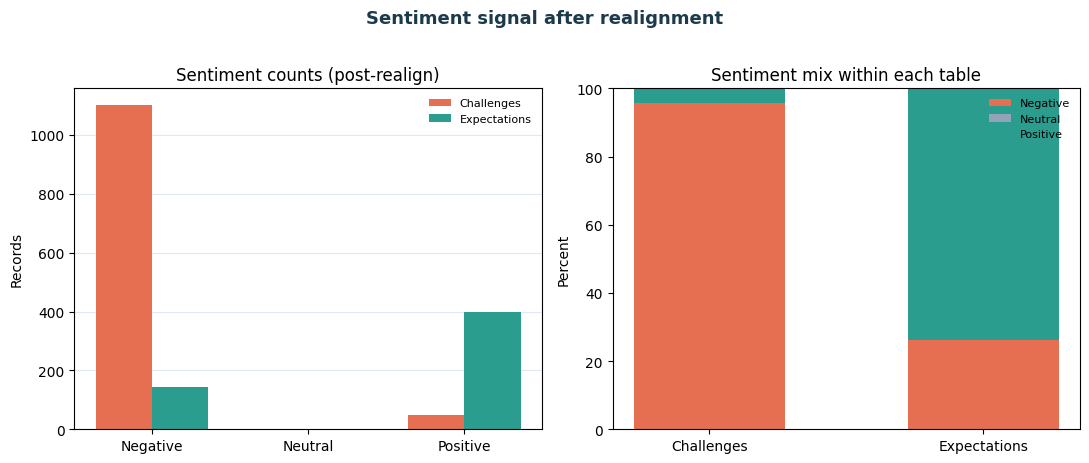

In [9]:
CORAL = "#E76F51"
TEAL = "#2A9D8F"
MUTED = "#94A3B8"
NAVY = "#1B3A4B"

order = ["negative", "neutral", "positive"]
colors = {"negative": CORAL, "neutral": MUTED, "positive": TEAL}


def counts(frame: pd.DataFrame) -> list[int]:
    vc = frame["sentiment"].value_counts()
    return [int(vc.get(s, 0)) for s in order]


def pct(vals: list[int]) -> list[float]:
    total = sum(vals) or 1
    return [100 * v / total for v in vals]


# --- Validation: realign should clear these meeting_notes mismatches ---
pos_in_challenges = challenges.loc[
    (challenges["source"] == SOURCE_MEETING_NOTES)
    & (challenges["sentiment"] == "positive")
]
neg_in_expectations = expectations.loc[
    (expectations["source"] == SOURCE_MEETING_NOTES)
    & (expectations["sentiment"] == "negative")
]

print("Post-realign validation (meeting_notes only)")
print(f"  Positive challenges remaining: {len(pos_in_challenges)} (expect 0)")
print(f"  Negative expectations remaining: {len(neg_in_expectations)} (expect 0)")
if len(pos_in_challenges) or len(neg_in_expectations):
    display(Markdown("**Still misfiled after realign — inspect below**"))
    if len(pos_in_challenges):
        display(pos_in_challenges)
    if len(neg_in_expectations):
        display(neg_in_expectations)
else:
    print("  OK — no meeting_notes polarity mismatches left in the wrong table.")

print("\nSentiment counts after realign:")
print("  Challenges:", dict(zip(order, counts(challenges))))
print("  Expectations:", dict(zip(order, counts(expectations))))

ch, ex = counts(challenges), counts(expectations)
x = np.arange(len(order))
w = 0.36

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(x - w / 2, ch, width=w, color=CORAL, label="Challenges")
axes[0].bar(x + w / 2, ex, width=w, color=TEAL, label="Expectations")
axes[0].set_xticks(x)
axes[0].set_xticklabels([s.title() for s in order])
axes[0].set_ylabel("Records")
axes[0].set_title("Sentiment counts (post-realign)")
axes[0].legend(frameon=False, fontsize=8)
axes[0].set_axisbelow(True)
axes[0].yaxis.grid(True, color="#E2E8F0", lw=0.8)

ch_p, ex_p = pct(ch), pct(ex)
bottom = np.zeros(2)
for i, sent in enumerate(order):
    vals = [ch_p[i], ex_p[i]]
    axes[1].bar(
        ["Challenges", "Expectations"],
        vals,
        bottom=bottom,
        color=colors[sent],
        label=sent.title(),
        width=0.55,
    )
    bottom = bottom + vals
axes[1].set_ylim(0, 100)
axes[1].set_ylabel("Percent")
axes[1].set_title("Sentiment mix within each table")
axes[1].legend(frameon=False, fontsize=8, loc="upper right")

fig.suptitle(
    "Sentiment signal after realignment",
    fontsize=13,
    fontweight="bold",
    color=NAVY,
    y=1.02,
)
fig.tight_layout()
fig_path = ROOT / "output" / "figures" / "sentiment_mix_post_realign.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_path, dpi=180, bbox_inches="tight", facecolor="white")
print(f"Saved {fig_path}")
plt.show()


## 4. Categorize records

Hybrid: body keywords → semantic similarity.


In [10]:
challenges, expectations, challenge_embeddings, embedder = run_categorize(
    challenges, expectations
)

# run_categorize only returns challenge embeddings; embed expectations too (reusing the
# categorize_text column it added) so they can be clustered the same way.
expectation_embeddings = embedder.encode(
    expectations["categorize_text"].tolist(),
    normalize_embeddings=True,
    show_progress_bar=True,
    batch_size=64,
)

print("Challenge categories:\n", challenges["Category"].value_counts().to_string())
print("\nExpectation categories:\n", expectations["Category"].value_counts().to_string())

Batches:   0%|          | 0/18 [00:00<?, ?it/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Challenge categories:
 Category
Case Management                     273
User Experience & Performance       185
Records & Document Management       179
Workflow & Business Processes       115
Data Management & Visibility        104
System Integration                   95
Scheduling & Resource Management     77
Communication & Collaboration        63
Training & Documentation             35
Reporting & Decision Support         25

Expectation categories:
 Category
Case Management                     93
User Experience & Performance       88
Records & Document Management       88
System Integration                  52
Scheduling & Resource Management    49
Data Management & Visibility        46
Workflow & Business Processes       43
Communication & Collaboration       35
Training & Documentation            26
Reporting & Decision Support        20


## 5. Cluster challenges & expectations (UMAP + HDBSCAN)

In [11]:
def assign_cluster_names(
    frame: pd.DataFrame,
    cluster_col: str = "Cluster",
    category_col: str = "Category",
    output_col: str = "Cluster_Label",
) -> tuple[pd.DataFrame, pd.DataFrame]:
    cluster_summary = (
        frame.groupby([cluster_col, category_col]).size().reset_index(name="Count")
    )
    dominant = (
        cluster_summary.sort_values("Count", ascending=False)
        .drop_duplicates(subset=[cluster_col])
        [[cluster_col, category_col]]
        .rename(columns={category_col: output_col})
    )
    return frame.merge(dominant, on=cluster_col, how="left"), cluster_summary


def soft_assign_noise(
    coords: np.ndarray,
    labels: np.ndarray,
    radius_percentile: float = 92,
    radius_slack: float = 1.35,
) -> tuple[np.ndarray, int]:
    """Pull leftover noise into the nearest cluster if it sits inside that cluster's envelope."""
    out = labels.copy()
    clustered = out != -1
    if not clustered.any():
        return out, 0

    centroids, radii = {}, {}
    for cid in sorted(set(out[clustered])):
        pts = coords[out == cid]
        centroids[cid] = pts.mean(axis=0)
        dists = np.linalg.norm(pts - centroids[cid], axis=1)
        radii[cid] = float(np.percentile(dists, radius_percentile) * radius_slack)

    assigned = 0
    for i in np.where(out == -1)[0]:
        best_c, best_d = None, np.inf
        for cid, center in centroids.items():
            d = float(np.linalg.norm(coords[i] - center))
            if d < best_d:
                best_c, best_d = cid, d
        if best_c is not None and best_d <= radii[best_c]:
            out[i] = best_c
            assigned += 1
    return out, assigned


TARGET_CLUSTERS = len(CATEGORY_CONFIG)
# Prefer coverage over ultra-tight cores (prior sweep left ~36% as noise).
NOISE_PENALTY = 1.35
CLUSTER_COUNT_PENALTY = 0.012


def cluster_frame(frame, embeddings, label):
    """UMAP + HDBSCAN param sweep, soft-assign noise, then name clusters by majority category."""
    reduced = umap.UMAP(
        n_neighbors=15, n_components=12, min_dist=0.0, metric="cosine", random_state=42
    ).fit_transform(embeddings)

    candidate_params = sorted({
        (mcs, ms, method)
        for mcs in range(5, 14)
        for ms in (1, 2, 3, max(1, mcs // 3))
        for method in ("eom", "leaf")
    })

    sweep_rows, best_labels, best_params, best_score = [], None, None, -np.inf
    n_rows = max(len(frame), 1)
    for mcs, ms, method in candidate_params:
        labels = hdbscan.HDBSCAN(
            min_cluster_size=mcs,
            min_samples=ms,
            metric="euclidean",
            cluster_selection_method=method,
        ).fit_predict(reduced)

        mask = labels != -1
        n_clusters = len(set(labels[mask]))
        noise = int((labels == -1).sum())
        noise_frac = noise / n_rows
        silhouette = (
            silhouette_score(reduced[mask], labels[mask], metric="euclidean")
            if mask.sum() > 1 and n_clusters > 1
            else -1.0
        )
        if noise_frac > 0.45 or n_clusters < 4 or n_clusters > 40:
            combined = -1.0
        else:
            combined = (
                silhouette
                - abs(n_clusters - TARGET_CLUSTERS) * CLUSTER_COUNT_PENALTY
                - noise_frac * NOISE_PENALTY
            )
        sweep_rows.append({
            "min_cluster_size": mcs, "min_samples": ms, "method": method,
            "clusters": n_clusters, "noise": noise, "noise_pct": round(noise_frac * 100, 1),
            "silhouette": round(float(silhouette), 4), "combined_score": round(float(combined), 4),
        })
        if combined > best_score:
            best_score, best_labels, best_params = combined, labels, (mcs, ms, method)

    # Fallback if every candidate was rejected (e.g. a small frame).
    if best_labels is None:
        best_params = (5, 1, "eom")
        best_labels = hdbscan.HDBSCAN(
            min_cluster_size=5, min_samples=1, metric="euclidean",
            cluster_selection_method="eom",
        ).fit_predict(reduced)

    print(f"[{label}] Best HDBSCAN params: {best_params} score: {round(float(best_score), 4)}")
    display(pd.DataFrame(sweep_rows).sort_values("combined_score", ascending=False).head(5))

    raw_labels = best_labels.copy()
    raw_noise = int((raw_labels == -1).sum())
    best_labels, n_soft = soft_assign_noise(reduced, best_labels)
    print(
        f"[{label}] Soft-assigned {n_soft} noise points "
        f"(noise {raw_noise} → {int((best_labels == -1).sum())})"
    )

    frame = frame.copy()
    frame["Cluster_Raw"] = raw_labels
    frame["Cluster"] = best_labels
    frame["Assign_Status"] = np.where(
        raw_labels != -1,
        "HDBSCAN cluster",
        np.where(best_labels != -1, "Soft-assigned", "Unclustered"),
    )
    frame, summary = assign_cluster_names(frame)
    frame.loc[frame["Cluster"] == -1, "Cluster_Label"] = "Noise / unclustered"

    print(f"[{label}] Assignment status:")
    print(frame["Assign_Status"].value_counts().to_string())
    print(
        f"[{label}] Unclustered: {(frame['Cluster'] == -1).sum()} / {len(frame)} "
        f"({100 * (frame['Cluster'] == -1).mean():.1f}%)\n"
    )
    return frame, reduced, summary


challenges, challenge_reduced, challenge_cluster_summary = cluster_frame(
    challenges, challenge_embeddings, "challenges"
)
expectations, expectation_reduced, expectation_cluster_summary = cluster_frame(
    expectations, expectation_embeddings, "expectations"
)

/Users/lilscott/Code/IPS/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[challenges] Best HDBSCAN params: (12, 2, 'eom') score: 0.1066


,min_cluster_size,min_samples,method,clusters,noise,noise_pct,silhouette,combined_score
44,12,2,eom,24,179,15.6,0.4846,0.1066
48,12,4,eom,23,203,17.6,0.4987,0.1046
52,13,2,eom,22,203,17.6,0.4832,0.1011
56,13,4,eom,21,227,19.7,0.4960,0.0977
46,12,3,eom,24,223,19.4,0.5134,0.0838


[challenges] Soft-assigned 77 noise points (noise 179 → 102)
[challenges] Assignment status:
Assign_Status
HDBSCAN cluster    972
Unclustered        102
Soft-assigned       77
[challenges] Unclustered: 102 / 1151 (8.9%)



/Users/lilscott/Code/IPS/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[expectations] Best HDBSCAN params: (12, 1, 'eom') score: 0.1256


,min_cluster_size,min_samples,method,clusters,noise,noise_pct,silhouette,combined_score
42,12,1,eom,17,62,11.5,0.3646,0.1256
36,11,1,eom,19,64,11.9,0.3921,0.1241
50,13,1,eom,16,74,13.7,0.3675,0.1105
51,13,1,leaf,17,82,15.2,0.3985,0.1095
44,12,2,eom,17,76,14.1,0.3738,0.0998


[expectations] Soft-assigned 45 noise points (noise 62 → 17)
[expectations] Assignment status:
Assign_Status
HDBSCAN cluster    478
Soft-assigned       45
Unclustered         17
[expectations] Unclustered: 17 / 540 (3.1%)



### Soft assignment map

2D projection of the same UMAP space used for HDBSCAN, for challenges and
expectations. Color by assignment status to see which points were dense cores,
which were rescued by soft assignment, and which stayed unclustered.

In [12]:
def soft_assignment_map(frame, embeddings, text_col, title):
    coords = umap.UMAP(
        n_neighbors=15, n_components=2, min_dist=0.1, metric="cosine", random_state=42
    ).fit_transform(embeddings)
    plot = pd.DataFrame({
        "x": coords[:, 0],
        "y": coords[:, 1],
        "Assign_Status": frame["Assign_Status"].values,
        "Cluster_Label": frame["Cluster_Label"].values,
        "Category": frame["Category"].values,
        "Focus Group": frame["focus_group"].values,
        "Record": frame[text_col].values,
    })
    fig = px.scatter(
        plot, x="x", y="y", color="Assign_Status",
        hover_data=["Focus Group", "Cluster_Label", "Category", "Record"],
        title=title,
        color_discrete_map={
            "HDBSCAN cluster": "#2A9D8F", "Soft-assigned": "#E9C46A", "Unclustered": "#E76F51",
        },
    )
    fig.update_layout(height=560, width=1100, template="plotly_white")
    fig.show()


soft_assignment_map(challenges, challenge_embeddings, CHALLENGE_TEXT_COL,
                    "Challenges — soft assignment map (UMAP 2D)")
soft_assignment_map(expectations, expectation_embeddings, EXPECTATION_TEXT_COL,
                    "Expectations — soft assignment map (UMAP 2D)")

/Users/lilscott/Code/IPS/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/lilscott/Code/IPS/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### Cluster contents

Cluster sizes for challenges and expectations, including noise (`Cluster == -1`).

In [13]:
def cluster_sizes(frame, text_col, label):
    cols = [
        c for c in [
            "Cluster", "Cluster_Label", "Assign_Status", "focus_group",
            text_col, "Category", "source",
        ] if c in frame.columns
    ]
    show = frame[cols].sort_values(["Cluster", "Assign_Status", "focus_group"]).reset_index(drop=True)
    print(f"[{label}] Cluster sizes (including unclustered):")
    display(
        show.groupby(["Cluster", "Cluster_Label"], as_index=False)
        .size()
        .rename(columns={"size": "Count"})
        .sort_values("Cluster")
    )


cluster_sizes(challenges, CHALLENGE_TEXT_COL, "challenges")
cluster_sizes(expectations, EXPECTATION_TEXT_COL, "expectations")

[challenges] Cluster sizes (including unclustered):


,Cluster,Cluster_Label,Count
0,-1,Noise / unclustered,102
1,0,System Integration,16
2,1,User Experience & Performance,107
3,2,User Experience & Performance,18
4,3,Data Management & Visibility,152
5,4,Case Management,56
6,5,Case Management,89
7,6,User Experience & Performance,15
8,7,User Experience & Performance,14
9,8,User Experience & Performance,52


[expectations] Cluster sizes (including unclustered):


,Cluster,Cluster_Label,Count
0,-1,Noise / unclustered,17
1,0,Scheduling & Resource Management,16
2,1,Case Management,38
3,2,System Integration,34
4,3,Case Management,14
5,4,User Experience & Performance,24
6,5,User Experience & Performance,61
7,6,System Integration,13
8,7,Reporting & Decision Support,30
9,8,User Experience & Performance,71


## 6. Visualizations


In [14]:
def semantic_map(frame, embeddings, text_col, title):
    coords = umap.UMAP(
        n_neighbors=15, n_components=2, min_dist=0.1, metric="cosine", random_state=42
    ).fit_transform(embeddings)
    plot = pd.DataFrame({
        "x": coords[:, 0],
        "y": coords[:, 1],
        "Category": frame["Category"].values,
        "Cluster_Label": frame["Cluster_Label"].values,
        "Record": frame[text_col].values,
        "Focus Group": frame["focus_group"].values,
    })
    fig = px.scatter(
        plot, x="x", y="y", color="Category",
        hover_data=["Focus Group", "Cluster_Label", "Record"], title=title,
    )
    fig.update_layout(height=560, width=1100, template="plotly_white")
    fig.show()


semantic_map(challenges, challenge_embeddings, CHALLENGE_TEXT_COL,
             "Challenges — 2D semantic map by category")
semantic_map(expectations, expectation_embeddings, EXPECTATION_TEXT_COL,
             "Expectations — 2D semantic map by category")

/Users/lilscott/Code/IPS/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/lilscott/Code/IPS/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [15]:
# show the expectation records that start with "(to keep)" for the IPS likes

IPS_likes = expectations[expectations["expectations"].str.startswith("(to keep)")]
IPS_likes.to_csv(IPS_LIKES_CSV, index=False, encoding="utf-8-sig")


## 6b. Reconcile categories → `final_category`

**Cluster purity** = share of a cluster whose per-record `Category` matches the
cluster's dominant label (`Cluster_Label`). `final_category` keeps the record's own
category when it is confident, but adopts the cluster label when the record is
low-confidence *and* lives in a pure cluster.

In [16]:
def add_final_category(frame, purity_threshold=0.6, low_conf=3.0):
    """Blend per-record Category with the cluster's dominant label (Cluster_Label)."""
    frame = frame.copy()
    match = frame["Category"] == frame["Cluster_Label"]
    purity = match.groupby(frame["Cluster"]).transform("mean")
    frame["Cluster_Purity"] = np.where(frame["Cluster"] == -1, np.nan, purity)

    frame["final_category"] = frame["Category"]
    take_cluster = (
        (frame["Cluster"] != -1)
        & (frame["Cluster_Purity"] >= purity_threshold)
        & (frame["Category_Confidence"] < low_conf)
    )
    frame.loc[take_cluster, "final_category"] = frame.loc[take_cluster, "Cluster_Label"]
    frame["Category_Reassigned"] = frame["final_category"] != frame["Category"]
    return frame


challenges = add_final_category(challenges)
expectations = add_final_category(expectations)

for label, frame in [("challenges", challenges), ("expectations", expectations)]:
    n = int(frame["Category_Reassigned"].sum())
    print(f"{label}: {n}/{len(frame)} records took the cluster label "
          f"({100 * n / len(frame):.1f}%)")

challenges: 17/1151 records took the cluster label (1.5%)
expectations: 10/540 records took the cluster label (1.9%)


## 7. Save categorized outputs


In [17]:
record_cols = [
    "department", "focus_group", "source","final_category", "sentiment",
    "Category", "Category_Confidence", "Category_Method", 
    "Cluster_Label", "Cluster_Purity", "Cluster", "Assign_Status",
]
challenge_cols = [c for c in ([CHALLENGE_TEXT_COL] + record_cols) if c in challenges.columns]
expectation_cols = [c for c in ([EXPECTATION_TEXT_COL] + record_cols) if c in expectations.columns]

challenges[challenge_cols].to_csv(CATEGORIZED_CHALLENGES_CSV, index=False, encoding="utf-8-sig")
expectations[expectation_cols].to_csv(CATEGORIZED_EXPECTATIONS_CSV, index=False, encoding="utf-8-sig")


def category_summary(frame, category_col="final_category"):
    return (
        frame.groupby(category_col, as_index=False).size()
        .rename(columns={"size": "Count", category_col: "Category"})
        .sort_values("Count", ascending=False)
    )


challenge_summary = category_summary(challenges)
expectation_summary = category_summary(expectations)
challenge_summary.to_csv(CATEGORY_SUMMARY_CSV, index=False, encoding="utf-8-sig")

with pd.ExcelWriter(CATEGORY_SUMMARY_XLSX, engine="openpyxl") as writer:
    challenge_summary.to_excel(writer, sheet_name="challenge_summary", index=False)
    expectation_summary.to_excel(writer, sheet_name="expectation_summary", index=False)
    challenges[challenge_cols].to_excel(writer, sheet_name="categorized_challenges", index=False)
    expectations[expectation_cols].to_excel(writer, sheet_name="categorized_expectations", index=False)
    IPS_likes.to_excel(writer, sheet_name="IPS_likes", index=False)

print(f"Saved {CATEGORIZED_CHALLENGES_CSV} ({len(challenges)} rows)")
print(f"Saved {CATEGORIZED_EXPECTATIONS_CSV} ({len(expectations)} rows)")
print(f"Saved {CATEGORY_SUMMARY_CSV}")
print(f"Saved {CATEGORY_SUMMARY_XLSX} (sheets: challenge_summary, expectation_summary, "
      "categorized_challenges, categorized_expectations, IPS_likes)")

print("\nChallenge final categories:")
display(challenge_summary)
print("Expectation final categories:")
display(expectation_summary)

Saved /Users/lilscott/Code/IPS/output/processed/categorized_challenges.csv (1151 rows)
Saved /Users/lilscott/Code/IPS/output/processed/categorized_expectations.csv (540 rows)
Saved /Users/lilscott/Code/IPS/output/processed/category_summary.csv
Saved /Users/lilscott/Code/IPS/output/processed/category_summary.xlsx (sheets: challenge_summary, expectation_summary, categorized_challenges, categorized_expectations, IPS_likes)

Challenge final categories:


,Category,Count
0,Case Management,285
8,User Experience & Performance,185
3,Records & Document Management,176
9,Workflow & Business Processes,113
2,Data Management & Visibility,102
6,System Integration,95
5,Scheduling & Resource Management,74
1,Communication & Collaboration,62
7,Training & Documentation,35
4,Reporting & Decision Support,24


Expectation final categories:


,Category,Count
0,Case Management,98
8,User Experience & Performance,87
3,Records & Document Management,86
6,System Integration,53
5,Scheduling & Resource Management,49
2,Data Management & Visibility,45
9,Workflow & Business Processes,43
1,Communication & Collaboration,34
7,Training & Documentation,26
4,Reporting & Decision Support,19
